# LowResPT — Hα+[NII] line flux: Zero-shot & Fine-tune Evaluation

Mirrors `linear_probe_redshift.ipynb`, but regresses the **blended Hα+[NII] line
flux** from frozen / fine-tuned LowResPT embeddings.

Three things differ from the redshift probe (all because the target is an
**absolute emission-line flux**, not a scale-free quantity like z):

1. **Target = `line_ha_nii`** (DJA catalog). At PRISM resolution Hα and
   [NII]6548/6584 are blended, so the pure `line_ha` column is entirely
   unmeasured (NaN) — `line_ha_nii` is what the data (and the model) can access.
2. **asinh transform** on the target: line flux spans several decades AND can be
   negative (noise / non-detections), so plain log fails; `arcsinh` is signed-log.
3. **Absolute scale re-injected.** LowResPT normalises each spectrum to N(0,1),
   so the patch tokens carry only the line **shape / EW** — the continuum's
   absolute level (needed for absolute flux = EW × continuum) lives in the
   per-sample `[mean, std]` stats. We append `asinh([mean,std])` to the
   embedding (`APPEND_STATS`); without it the probe can only learn EW, not flux.

Hα+[NII] (rest 6563Å) lands in the observed 1–2µm window only for z≈0.52–2.05,
so the sample is restricted to that range (outside it the line isn't in the
spectrum to learn from).

In [64]:
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from astropy.table import Table
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

from model.low_res_pt import LowResPT
from data.dataset import LowResDataset
from data.datamodule import LowResDataModule

# == Config ====================================================================
CKPT = "/home/yacheng/ssl_outthere/encoder_spectrum/LowResPT/outputs/low_res_pt_1_2_micron/version_0/checkpoints/epoch=epoch=387-val_hid_loss=val_hid_loss=0.1063.ckpt"
FITS = "/home/yacheng/ssl_outthere/images/DJA/DJA_spectra_v4.5.fits"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Target — blended Ha+[NII] line flux (pure line_ha is all-NaN at PRISM res).
TARGET_COL = "line_ha_nii"
TARGET_ERR = "line_ha_nii_err"

# Sample filters (applied when building the dataset).
MIN_SN50     = 0          # min median S/N; None = no cut
# Ha+[NII] (rest 6563A) is inside the observed 1-2um window only for z~0.52-2.05.
MIN_REDSHIFT = 1        # keep z >  MIN_REDSHIFT
MAX_REDSHIFT = 3        # keep z <= MAX_REDSHIFT
FRAC_VALID_PIX = 0.5      # drop near-empty spectra (degenerate all-zero embedding)
MIN_LINE_SNR = 5        # require line_ha_nii / err > this (0 = keep all, incl. non-detections)

# Target transform: plain log. flux<=0 (noise / non-detections) -> NaN and dropped below.
T     = lambda f: np.log(np.where(np.asarray(f) > 0, f, np.nan))
T_INV = lambda t: np.exp(t)

# Representation
POOL         = "concat"   # "concat" | "mean" | "max" | "meanmax"
APPEND_STATS = True       # append asinh([mean,std]) so the probe can recover ABSOLUTE flux

# Shared split + probes
SPLIT_FRAC = 0.5
KNN_K      = 5
FS_STEPS   = 500
FS_LR      = 1e-3
FS_WD      = 1e-4
ENC_LR     = 1e-4
BATCH_SIZE = 64
SEED       = 42
print(f"device={DEVICE}  target={TARGET_COL}  pool={POOL}  append_stats={APPEND_STATS}  "
      f"z in ({MIN_REDSHIFT}, {MAX_REDSHIFT}]  min_sn50={MIN_SN50}  frac_valid_pix={FRAC_VALID_PIX}")

device=cuda  target=line_ha_nii  pool=concat  append_stats=True  z in (1, 3]  min_sn50=0  frac_valid_pix=0.5


## Load frozen encoder

In [65]:
model = LowResPT.load_from_checkpoint(CKPT, map_location=DEVICE).eval().to(DEVICE)
print(f"loaded: embed_dim={model.embed_dim}  patch={model.hparams.patch_size}  stride={model.hparams.stride}")

loaded: embed_dim=64  patch=4  stride=2


## Helpers — embeddings (+stats), metrics, probes

In [66]:
def metrics(y, yp):
    # On the log-transformed flux (what is regressed). NMAD/out are robust scatter.
    d = yp - y
    return dict(
        r2   = r2_score(y, yp),
        mae  = mean_absolute_error(y, yp),
        rmse = float(np.sqrt(np.mean(d ** 2))),
        nmad = 1.4826 * np.median(np.abs(d - np.median(d))),
        out  = float(np.mean(np.abs(d) > 0.5)),          # |d log-flux| > 0.5
    )

def show(tag, m):
    print(f"{tag:26s} R2={m['r2']:.3f}  MAE={m['mae']:.3f}  RMSE={m['rmse']:.3f}  "
          f"NMAD={m['nmad']:.3f}  out={m['out']:.1%}")

@torch.no_grad()
def compute_embeddings(dataset, pool="concat", append_stats=APPEND_STATS, batch_size=256):
    # Frozen-encoder embedding for every spectrum (dataset order). Optionally append
    # asinh([mean,std]) so the representation carries the ABSOLUTE flux scale that
    # per-sample normalisation strips from the patch tokens (needed for absolute flux).
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, collate_fn=LowResDataModule._pad_collate)
    Xs = []
    for batch in loader:
        flux  = batch["flux"].to(DEVICE)
        wave  = batch["wavelength"].to(DEVICE)
        vmask = batch["valid_mask"].to(DEVICE)
        fn, mean, std = model._normalize_flux(flux, vmask, model.hparams.min_std)
        stats = torch.cat([mean, std], dim=-1)              # (B,2) absolute scale
        patches, wt, vp, tvm, _ = model._patchify(fn, wave, vmask)
        ps = model._compute_patch_stats(patches, vp)
        x  = model.encode(patches, wt, tvm, stats, patch_stats=ps)
        raw  = x[:, 1:, :]                                   # (B,N,D) patch tokens
        vm3  = tvm.float().unsqueeze(-1)
        tok  = raw * vm3
        mean_ = tok.sum(1) / vm3.sum(1).clamp(min=1)
        max_  = raw.masked_fill(tvm.unsqueeze(-1) == 0, float("-inf")).max(1).values
        max_  = torch.nan_to_num(max_, neginf=0.0)
        if   pool == "concat":  emb = tok.reshape(tok.shape[0], -1)
        elif pool == "mean":    emb = mean_
        elif pool == "max":     emb = max_
        elif pool == "meanmax": emb = torch.cat([mean_, max_], dim=-1)
        else: raise ValueError(pool)
        if append_stats:
            emb = torch.cat([emb, torch.asinh(stats)], dim=-1)   # +absolute flux scale
        Xs.append(emb.cpu().numpy())
    return np.concatenate(Xs)

def knn_zeroshot(X_tr, y_tr, X_va, k=KNN_K):
    sc = StandardScaler().fit(X_tr)
    knn = KNeighborsRegressor(n_neighbors=k, weights="distance")
    knn.fit(sc.transform(X_tr), y_tr)
    return knn.predict(sc.transform(X_va))

def plot_pred(ax, y, yp, title, color):
    m = metrics(y, yp)
    lo, hi = np.percentile(np.concatenate([y, yp]), [1, 99])
    ax.scatter(y, yp, s=5, alpha=0.2, color=color, rasterized=True)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1", alpha=0.3)
    xl = np.linspace(lo, hi, 100)
    ax.fill_between(xl, xl - 0.5, xl + 0.5, alpha=0.10, color="gray", label="+/-0.5")
    ax.set_xlabel(r"log($F_{H\alpha+[NII]}$) true"); ax.set_ylabel("pred")
    ax.set_title(f"{title}\nR2={m['r2']:.3f}  NMAD={m['nmad']:.3f}  out={m['out']:.1%}", fontsize=11)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
    return m

## Dataset, target (id-aligned), and the shared 50/50 split

In [67]:
ds = LowResDataset(FITS, min_sn50=MIN_SN50, min_redshift=MIN_REDSHIFT, max_redshift=MAX_REDSHIFT,
                   frac_valid_pix=FRAC_VALID_PIX)
X = compute_embeddings(ds, pool=POOL)
print(f"embeddings: X={X.shape}  pool={POOL}  append_stats={APPEND_STATS}")

# Target, ALIGNED to dataset order via ds.valid_indices (rows that passed the filters).
_tab    = Table.read(FITS)
ha_raw  = np.asarray(_tab[TARGET_COL])[ds.valid_indices].astype(np.float64)   # dataset order
ha_err  = np.asarray(_tab[TARGET_ERR])[ds.valid_indices].astype(np.float64)
del _tab

y_full = T(ha_raw)                                   # log-transformed (dataset order; NaN where flux<=0 / unmeasured)

# Keep rows with a finite measured line flux (and optional S/N detection cut).
finite = np.isfinite(ha_raw) & np.isfinite(y_full)
if MIN_LINE_SNR > 0:
    with np.errstate(invalid="ignore", divide="ignore"):
        finite &= np.isfinite(ha_err) & (ha_raw / ha_err > MIN_LINE_SNR)
keep = np.where(finite)[0]                            # positions into ds with a usable target
print(f"target {TARGET_COL}: {len(keep)}/{len(ds)} usable "
      f"(median F={np.nanmedian(ha_raw[keep]):.1f}, log range "
      f"[{y_full[keep].min():.2f}, {y_full[keep].max():.2f}])")

# Group-aware 50/50 split by objid (every spectrum of an object stays on one side),
# restricted to the usable-target rows. tr/va are positions into the FULL dataset.
from sklearn.model_selection import GroupShuffleSplit
obj = ds.objid
gss = GroupShuffleSplit(n_splits=1, train_size=SPLIT_FRAC, random_state=SEED)
rel_tr, rel_va = next(gss.split(keep, groups=obj[keep]))
tr, va = keep[rel_tr], keep[rel_va]
X_tr, X_va, y_tr, y_va = X[tr], X[va], y_full[tr], y_full[va]
n_overlap = len(set(obj[tr]) & set(obj[va]))
print(f"group split by objid: train={len(tr)}  val={len(va)}  objid overlap={n_overlap}")
assert n_overlap == 0, "objid leaked across split"

Converting flux from f_nu (uJy) to f_lambda (∝ f_nu / λ²) (use_jansky=True to disable this conversion)
grade in (1, 2, 3) filtering: 26486/42196 samples kept
sn50 >= 0 filtering: 25965/42196 samples kept
z_best > 1 filtering: 19392/42196 samples kept
z_best <= 3 filtering: 9588/42196 samples kept
valid_pix_frac > 0.5 filtering: 9256/42196 samples kept
LowResDataset: 9256 spectra, 56 pixels (1.004–1.991 µm)
embeddings: X=(9256, 1730)  pool=concat  append_stats=True
target line_ha_nii: 7706/9256 usable (median F=1111.4, log range [3.41, 13.80])
group split by objid: train=3868  val=3838  objid overlap=0


## Section A — Zero-shot (k-NN, no training)

== zero-shot k-NN (reference bank = 50% train half) ==


kNN k=1                    R2=0.364  MAE=0.725  RMSE=0.945  NMAD=0.835  out=54.8%
kNN k=5                    R2=0.557  MAE=0.603  RMSE=0.788  NMAD=0.707  out=48.3%
kNN k=10                   R2=0.558  MAE=0.601  RMSE=0.788  NMAD=0.722  out=48.7%
kNN k=20                   R2=0.542  MAE=0.610  RMSE=0.802  NMAD=0.737  out=50.1%


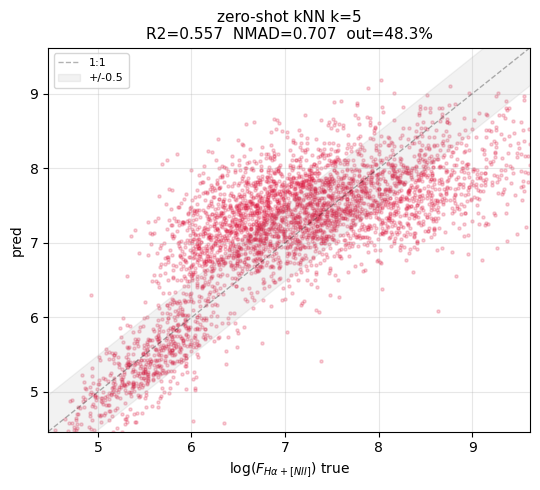

In [68]:
print("== zero-shot k-NN (reference bank = 50% train half) ==")
for k in (1, 5, 10, 20):
    show(f"kNN k={k}", metrics(y_va, knn_zeroshot(X_tr, y_tr, X_va, k)))
pred_zs = knn_zeroshot(X_tr, y_tr, X_va, KNN_K)

fig, ax = plt.subplots(figsize=(5.5, 5))
plot_pred(ax, y_va, pred_zs, f"zero-shot kNN k={KNN_K}", "crimson")
plt.tight_layout(); plt.show()

## Section D — Fine-tune (encoder unfrozen)

In [69]:
from torch.utils.data import Subset, Dataset as TorchDataset
from tqdm.auto import tqdm

class HaTargetDataset(TorchDataset):
    # Wrap LowResDataset to add the (already asinh-transformed) target so the
    # fine-tune loader carries it; collate stacks the 0-dim "target" scalar.
    def __init__(self, base, target):
        self.base = base; self.target = target
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        d = self.base[i]
        d["target"] = torch.tensor(np.float32(self.target[i]))
        return d

ds_t = HaTargetDataset(ds, y_full)

def encode_pooled(enc, batch, pool=POOL, append_stats=APPEND_STATS):
    # Trainable-encoder embedding (gradients flow into enc). Same pooling +stats as
    # compute_embeddings, so fine-tune and zero-shot share one representation.
    flux  = batch["flux"]; wave = batch["wavelength"]; vmask = batch["valid_mask"]
    fn, mean, std = enc._normalize_flux(flux, vmask, enc.hparams.min_std)
    stats = torch.cat([mean, std], dim=-1)
    patches, wt, vp, tvm, _ = enc._patchify(fn, wave, vmask)
    ps = enc._compute_patch_stats(patches, vp)
    x  = enc.encode(patches, wt, tvm, stats, patch_stats=ps)
    raw  = x[:, 1:, :]
    vm3  = tvm.float().unsqueeze(-1)
    tok  = raw * vm3
    mean_ = tok.sum(1) / vm3.sum(1).clamp(min=1)
    max_  = raw.masked_fill(tvm.unsqueeze(-1) == 0, float("-inf")).max(1).values
    max_  = torch.nan_to_num(max_, neginf=0.0)
    if   pool == "concat":  emb = tok.reshape(tok.shape[0], -1)
    elif pool == "mean":    emb = mean_
    elif pool == "max":     emb = max_
    elif pool == "meanmax": emb = torch.cat([mean_, max_], dim=-1)
    else: raise ValueError(pool)
    if append_stats:
        emb = torch.cat([emb, torch.asinh(stats)], dim=-1)
    return emb

def finetune(head_kind="linear", hidden=256, dropout=0.1, steps=FS_STEPS,
             head_lr=FS_LR, enc_lr=ENC_LR, wd=FS_WD, bs=BATCH_SIZE):
    # End-to-end fine-tune of a FRESH encoder copy + head, mini-batch SGD, same
    # split/steps/seed. Target standardised on the train half (asinh space).
    enc = LowResPT.load_from_checkpoint(CKPT, map_location=DEVICE).to(DEVICE)
    train_loader = DataLoader(Subset(ds_t, [int(i) for i in tr]), batch_size=bs,
                              shuffle=True, num_workers=0, drop_last=False,
                              collate_fn=LowResDataModule._pad_collate)
    val_loader   = DataLoader(Subset(ds_t, [int(i) for i in va]), batch_size=256,
                              shuffle=False, num_workers=0,
                              collate_fn=LowResDataModule._pad_collate)
    enc.eval()
    with torch.no_grad():
        probe = {k: v.to(DEVICE) for k, v in next(iter(val_loader)).items()}
        in_dim = encode_pooled(enc, probe).shape[1]

    torch.manual_seed(SEED)
    if head_kind == "linear":
        head = nn.Linear(in_dim, 1).to(DEVICE)
    elif head_kind == "mlp":
        head = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                             nn.Dropout(dropout), nn.Linear(hidden, 1)).to(DEVICE)
    else:
        raise ValueError(head_kind)

    ysc = StandardScaler().fit(y_tr.reshape(-1, 1))
    y_mean, y_std = float(ysc.mean_[0]), float(ysc.scale_[0])
    opt = torch.optim.Adam(
        [{"params": enc.parameters(),  "lr": enc_lr},
         {"params": head.parameters(), "lr": head_lr}], weight_decay=wd)

    enc.train(); head.train()
    step = 0; pbar = tqdm(total=steps, desc=f"Fine-tuning ({head_kind})")
    while step < steps:
        for batch in train_loader:
            if step >= steps: break
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            yb = (batch["target"].float().unsqueeze(1) - y_mean) / y_std
            opt.zero_grad()
            loss = nn.functional.mse_loss(head(encode_pooled(enc, batch)), yb)
            loss.backward(); opt.step(); step += 1; pbar.update(1)
    pbar.close()

    enc.eval(); head.eval(); preds = []
    with torch.no_grad():
        for batch in val_loader:                          # val in order -> matches y_va
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            preds.append(head(encode_pooled(enc, batch)).cpu().numpy())
    pred = ysc.inverse_transform(np.concatenate(preds)).squeeze(1)   # back to asinh-flux
    return pred, float(loss.item())

## D1 — Fine-tuned encoder + linear head

Fine-tuning (linear):   0%|          | 0/500 [00:00<?, ?it/s]

fine-tuned linear: 500 steps  enc_lr=0.0001  final train MSE=0.0875
fine-tuned linear          R2=0.902  MAE=0.247  RMSE=0.371  NMAD=0.241  out=10.3%


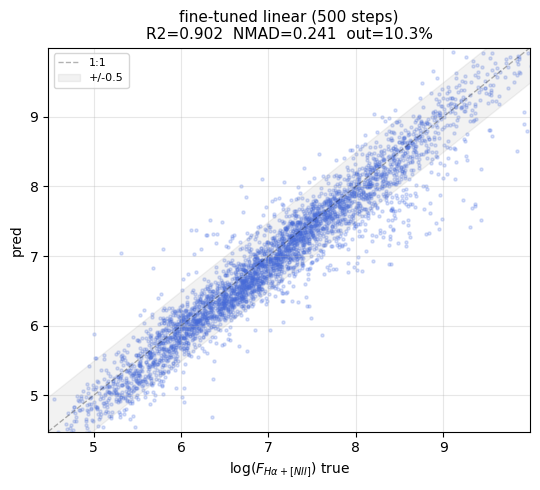

In [70]:
pred_ft_lin, ft_lin_mse = finetune("linear")
print(f"fine-tuned linear: {FS_STEPS} steps  enc_lr={ENC_LR}  final train MSE={ft_lin_mse:.4f}")
show("fine-tuned linear", metrics(y_va, pred_ft_lin))

fig, ax = plt.subplots(figsize=(5.5, 5))
plot_pred(ax, y_va, pred_ft_lin, f"fine-tuned linear ({FS_STEPS} steps)", "royalblue")
plt.tight_layout(); plt.show()

## D2 — Fine-tuned encoder + 2-layer MLP head

Fine-tuning (mlp):   0%|          | 0/500 [00:00<?, ?it/s]

fine-tuned MLP (2-layer, hidden=256): 500 steps  enc_lr=0.0001  final train MSE=0.1119
fine-tuned MLP (2-layer)   R2=0.904  MAE=0.251  RMSE=0.367  NMAD=0.263  out=11.4%


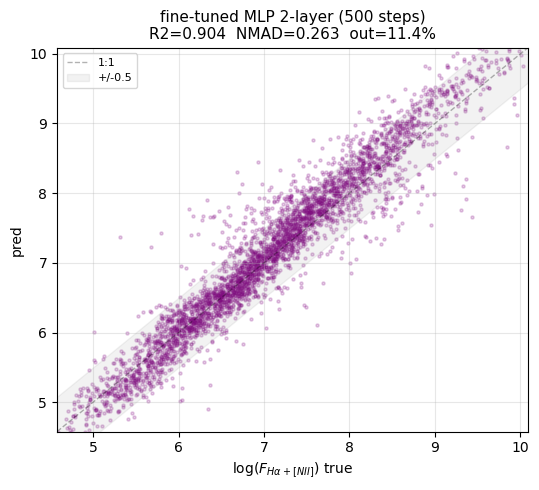

In [71]:
pred_ft_mlp, ft_mlp_mse = finetune("mlp", hidden=256, dropout=0.1)
print(f"fine-tuned MLP (2-layer, hidden=256): {FS_STEPS} steps  enc_lr={ENC_LR}  final train MSE={ft_mlp_mse:.4f}")
show("fine-tuned MLP (2-layer)", metrics(y_va, pred_ft_mlp))

fig, ax = plt.subplots(figsize=(5.5, 5))
plot_pred(ax, y_va, pred_ft_mlp, f"fine-tuned MLP 2-layer ({FS_STEPS} steps)", "purple")
plt.tight_layout(); plt.show()

## Summary — zero-shot vs fine-tuned (same val split)

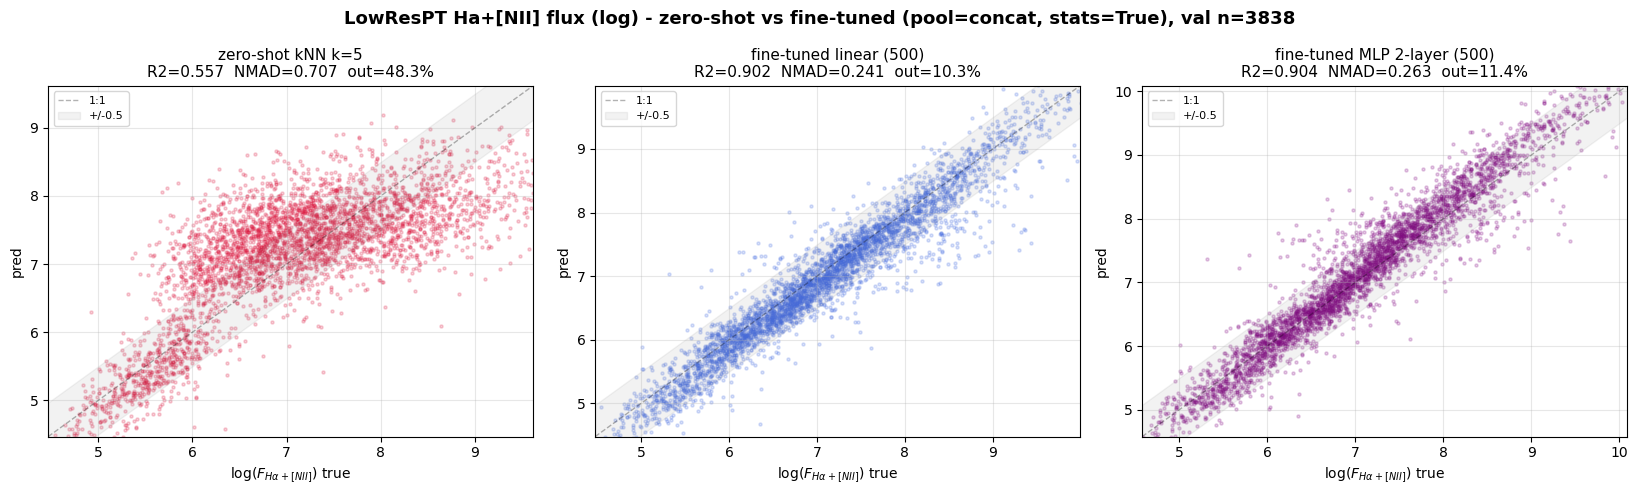

SUMMARY   val n=3838   z in (1,3]   target=line_ha_nii
          pool=concat  append_stats=True  FS_STEPS=500
zero-shot kNN              R2=0.557  MAE=0.603  RMSE=0.788  NMAD=0.707  out=48.3%
fine-tuned linear          R2=0.902  MAE=0.247  RMSE=0.371  NMAD=0.241  out=10.3%
fine-tuned MLP 2-layer     R2=0.904  MAE=0.251  RMSE=0.367  NMAD=0.263  out=11.4%


In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
m_zs   = plot_pred(axes[0], y_va, pred_zs,     f"zero-shot kNN k={KNN_K}",            "crimson")
m_ft_l = plot_pred(axes[1], y_va, pred_ft_lin, f"fine-tuned linear ({FS_STEPS})",     "royalblue")
m_ft_m = plot_pred(axes[2], y_va, pred_ft_mlp, f"fine-tuned MLP 2-layer ({FS_STEPS})","purple")
plt.suptitle(f"LowResPT Ha+[NII] flux (log) - zero-shot vs fine-tuned (pool={POOL}, "
             f"stats={APPEND_STATS}), val n={len(y_va)}", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("="*62)
print(f"SUMMARY   val n={len(y_va)}   z in ({MIN_REDSHIFT},{MAX_REDSHIFT}]   target={TARGET_COL}")
print(f"          pool={POOL}  append_stats={APPEND_STATS}  FS_STEPS={FS_STEPS}")
print("="*62)
show("zero-shot kNN",         m_zs)
show("fine-tuned linear",     m_ft_l)
show("fine-tuned MLP 2-layer",m_ft_m)